In [31]:

import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

complex_labels = {
    "complex_i": "Complex I",
    "complex_ii": "Complex II",
    "complex_iii": "Complex III",
    "complex_iv": "Complex IV",
    "complex_v": "Complex V"
}


STRING_DIR = "../data/interim/STRING_output"

subtypes = [
    "classical",
    "mesenchymal",
    "proneural"
]

PATHWAY_DIR = "../data/processed/new_pathway_diff"
OXPHOS_DIR = "../data/processed/new_oxphos"

pathways = [
    "Apoptosis",
    "Autophagy",
    "Ferroptosis",
    "Necroptosis",
    "Pyroptosis"
]

complexes = [
    "complex_i",
    "complex_ii",
    "complex_iii",
    "complex_iv",
    "complex_v"
]

graphs = {}



for subtype in subtypes:

    from collections import defaultdict

    gene_annotation = defaultdict(lambda: {
        "pathways": set(),
        "complexes": set()
    })
    
    gene_log2fc = {}
    ####################################################
    # Load pathway annotations
    ####################################################
    
    for pathway in pathways:

        file = os.path.join(
            PATHWAY_DIR,
            subtype,
            f"{subtype}_{pathway}_diff.csv"
        )

        df = pd.read_csv(file, index_col=0)

        df.index = df.index.astype(str).str.upper()

        for gene in df.index:

            gene_annotation[gene]["pathways"].add(pathway)

            # store log2FC
            gene_log2fc[gene] = df.loc[gene, "log2FC"]
    ####################################################
    # Load complex annotations
    ####################################################

    for complex_name in complexes:

        file = os.path.join(
            OXPHOS_DIR,
            f"{subtype}_{complex_name}.csv"
        )

        df = pd.read_csv(file, index_col=0)

        df.index = df.index.astype(str).str.upper()

        for gene in df.index:
            gene_annotation[gene]["complexes"].add(
                complex_labels[complex_name]
            )

        for gene in df.index:

                gene_annotation[gene]["complexes"].add(
                    complex_labels[complex_name]
                )

                # also store log2FC for complex genes
                gene_log2fc[gene] = df.loc[gene, "log2FC"]

    ####################################################
    # Load STRING network
    ####################################################

    file = os.path.join(
        STRING_DIR,
        f"{subtype}_string_interactions.tsv"
    )

    interactions = pd.read_csv(
        file,
        sep="\t"
    )

    G = nx.from_pandas_edgelist(
        interactions,
        source="#node1",
        target="node2",
        edge_attr=True,
        create_using=nx.Graph()
    )

    graphs[subtype] = G

    for gene in G.nodes():

        G.nodes[gene]["Pathways"] = list(
            gene_annotation[gene]["pathways"]
        )

        G.nodes[gene]["Complexes"] = list(
            gene_annotation[gene]["complexes"]
        )

        G.nodes[gene]["log2FC"] = gene_log2fc.get(gene, 0)

    annotation = []

    for gene in G.nodes():

        annotation.append({

            "Gene": gene,

            "Pathways": ";".join(G.nodes[gene]["Pathways"]),

            "Complexes": ";".join(G.nodes[gene]["Complexes"])

        })

    annotation = pd.DataFrame(annotation)

    annotation.to_csv(
        f"../data/interim/network_stat/{subtype}/{subtype}_annotations.csv",
        index=False
    )
    

    
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G)
    closeness = nx.closeness_centrality(G)
    pagerank = nx.pagerank(G)

    stats = pd.DataFrame({
        "Gene": list(G.nodes()),
        "Degree": [degree[g] for g in G.nodes()],
        "Betweenness": [betweenness[g] for g in G.nodes()],
        "Closeness": [closeness[g] for g in G.nodes()],
        "PageRank": [pagerank[g] for g in G.nodes()]
    })

    stats.sort_values(
        "Degree",
        ascending=False
    ).to_csv(
        os.path.join(

            f"../data/interim/network_stat/{subtype}/{subtype}_network_statistics.csv"
        ),
        index=False
    )
    print(f"{subtype.capitalize()}")
    print(f"Nodes : {G.number_of_nodes()}")
    print(f"Edges : {G.number_of_edges()}")
    print("-" * 30)


Classical
Nodes : 424
Edges : 4331
------------------------------
Mesenchymal
Nodes : 450
Edges : 4514
------------------------------
Proneural
Nodes : 415
Edges : 4247
------------------------------


C:\Users\haina\AppData\Local\Temp\ipykernel_24896\1553038459.py:356: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


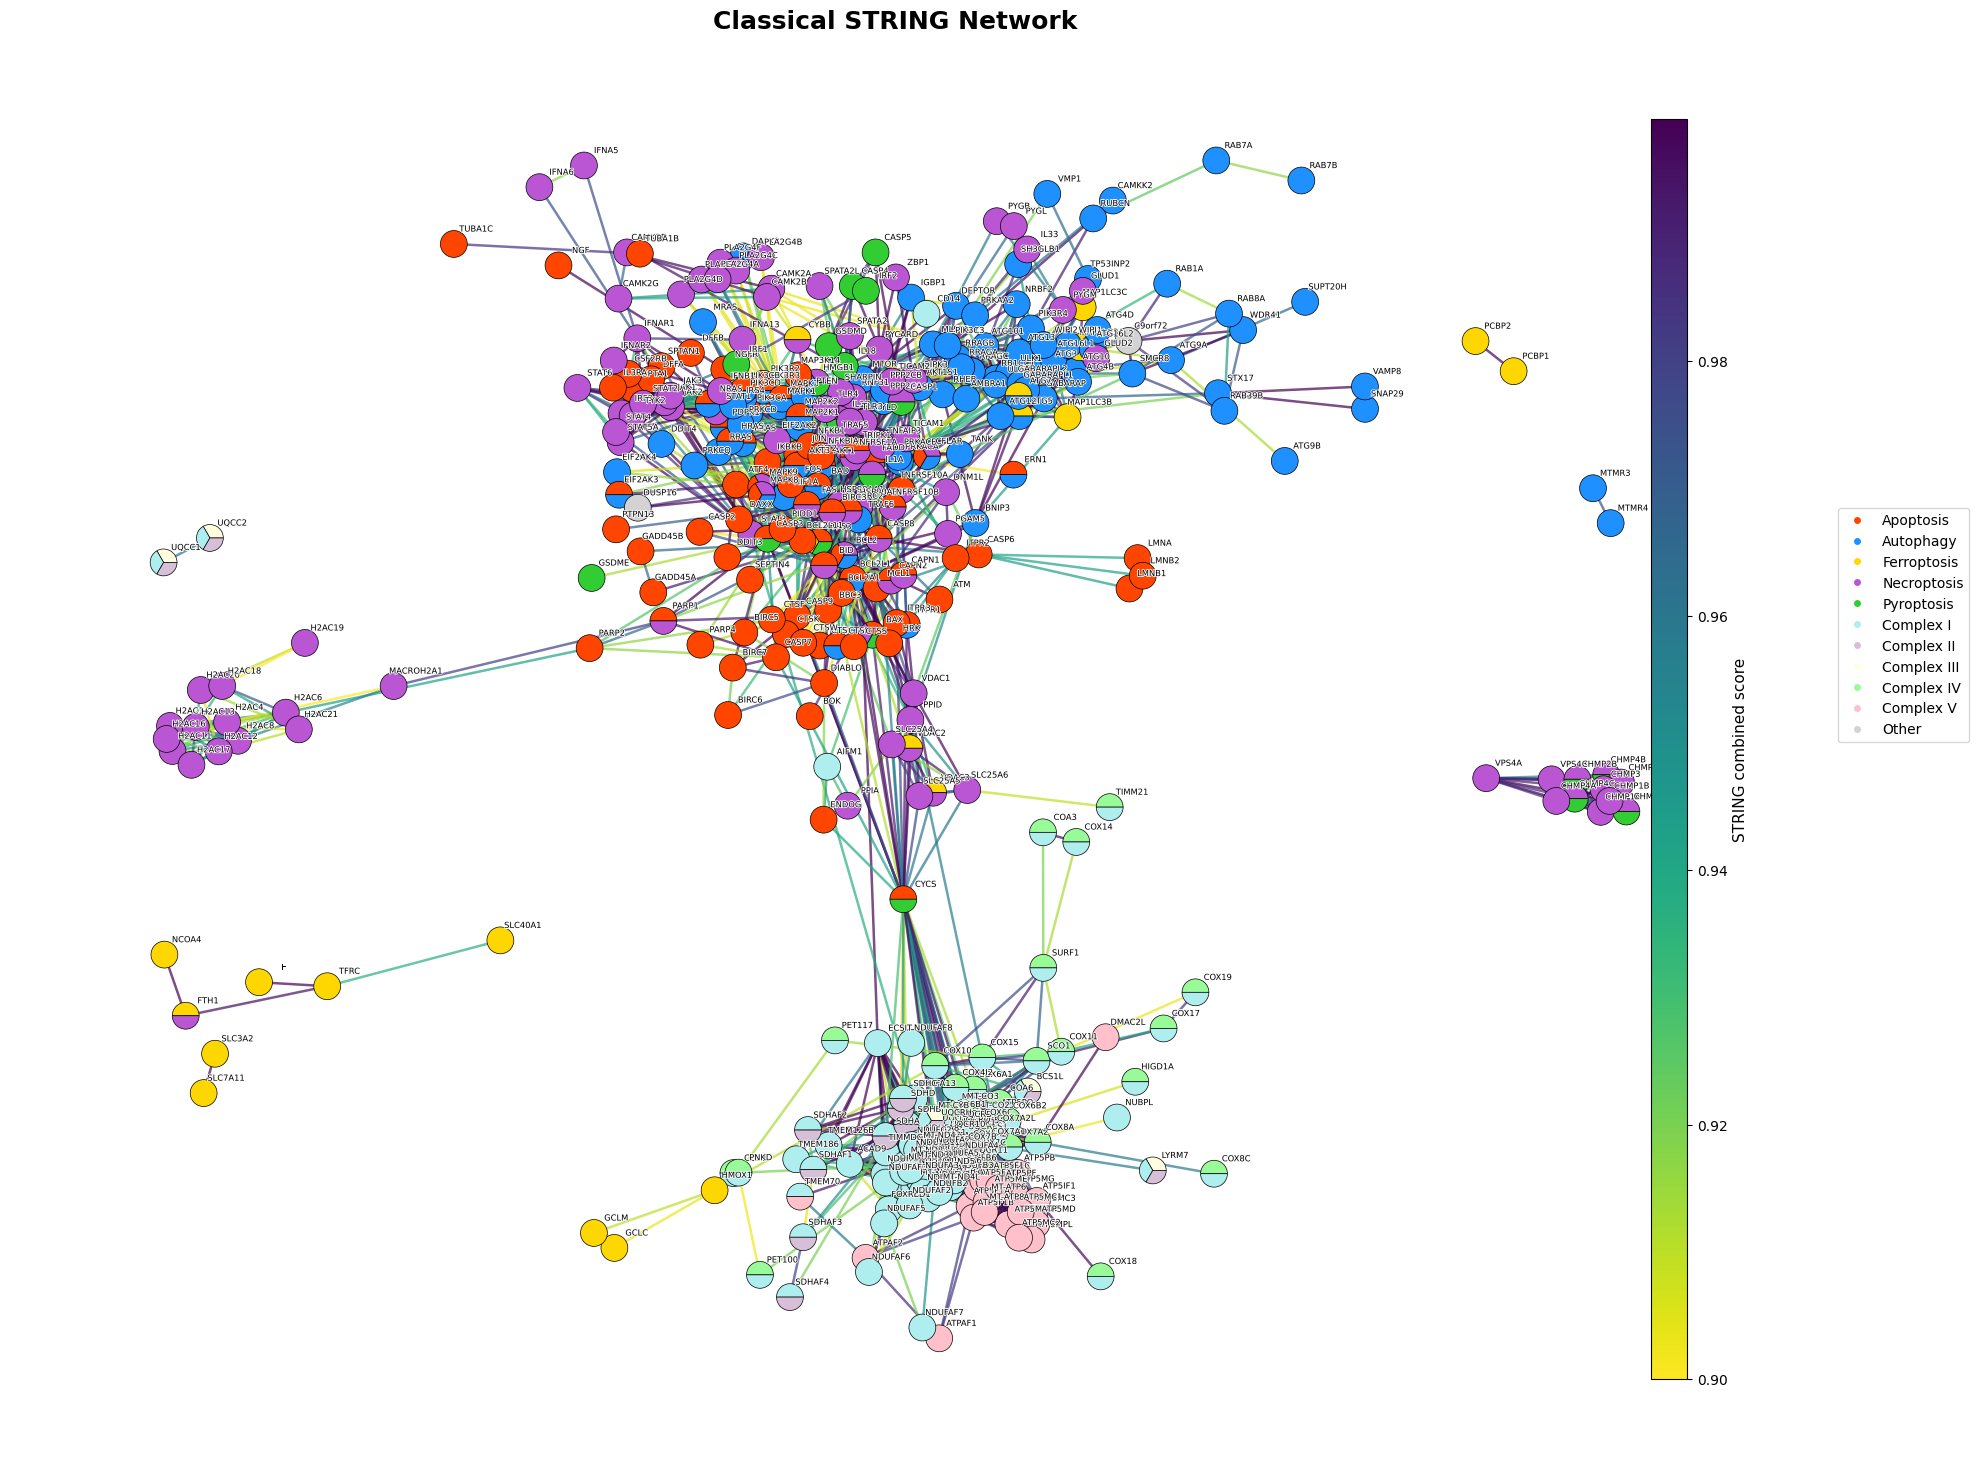

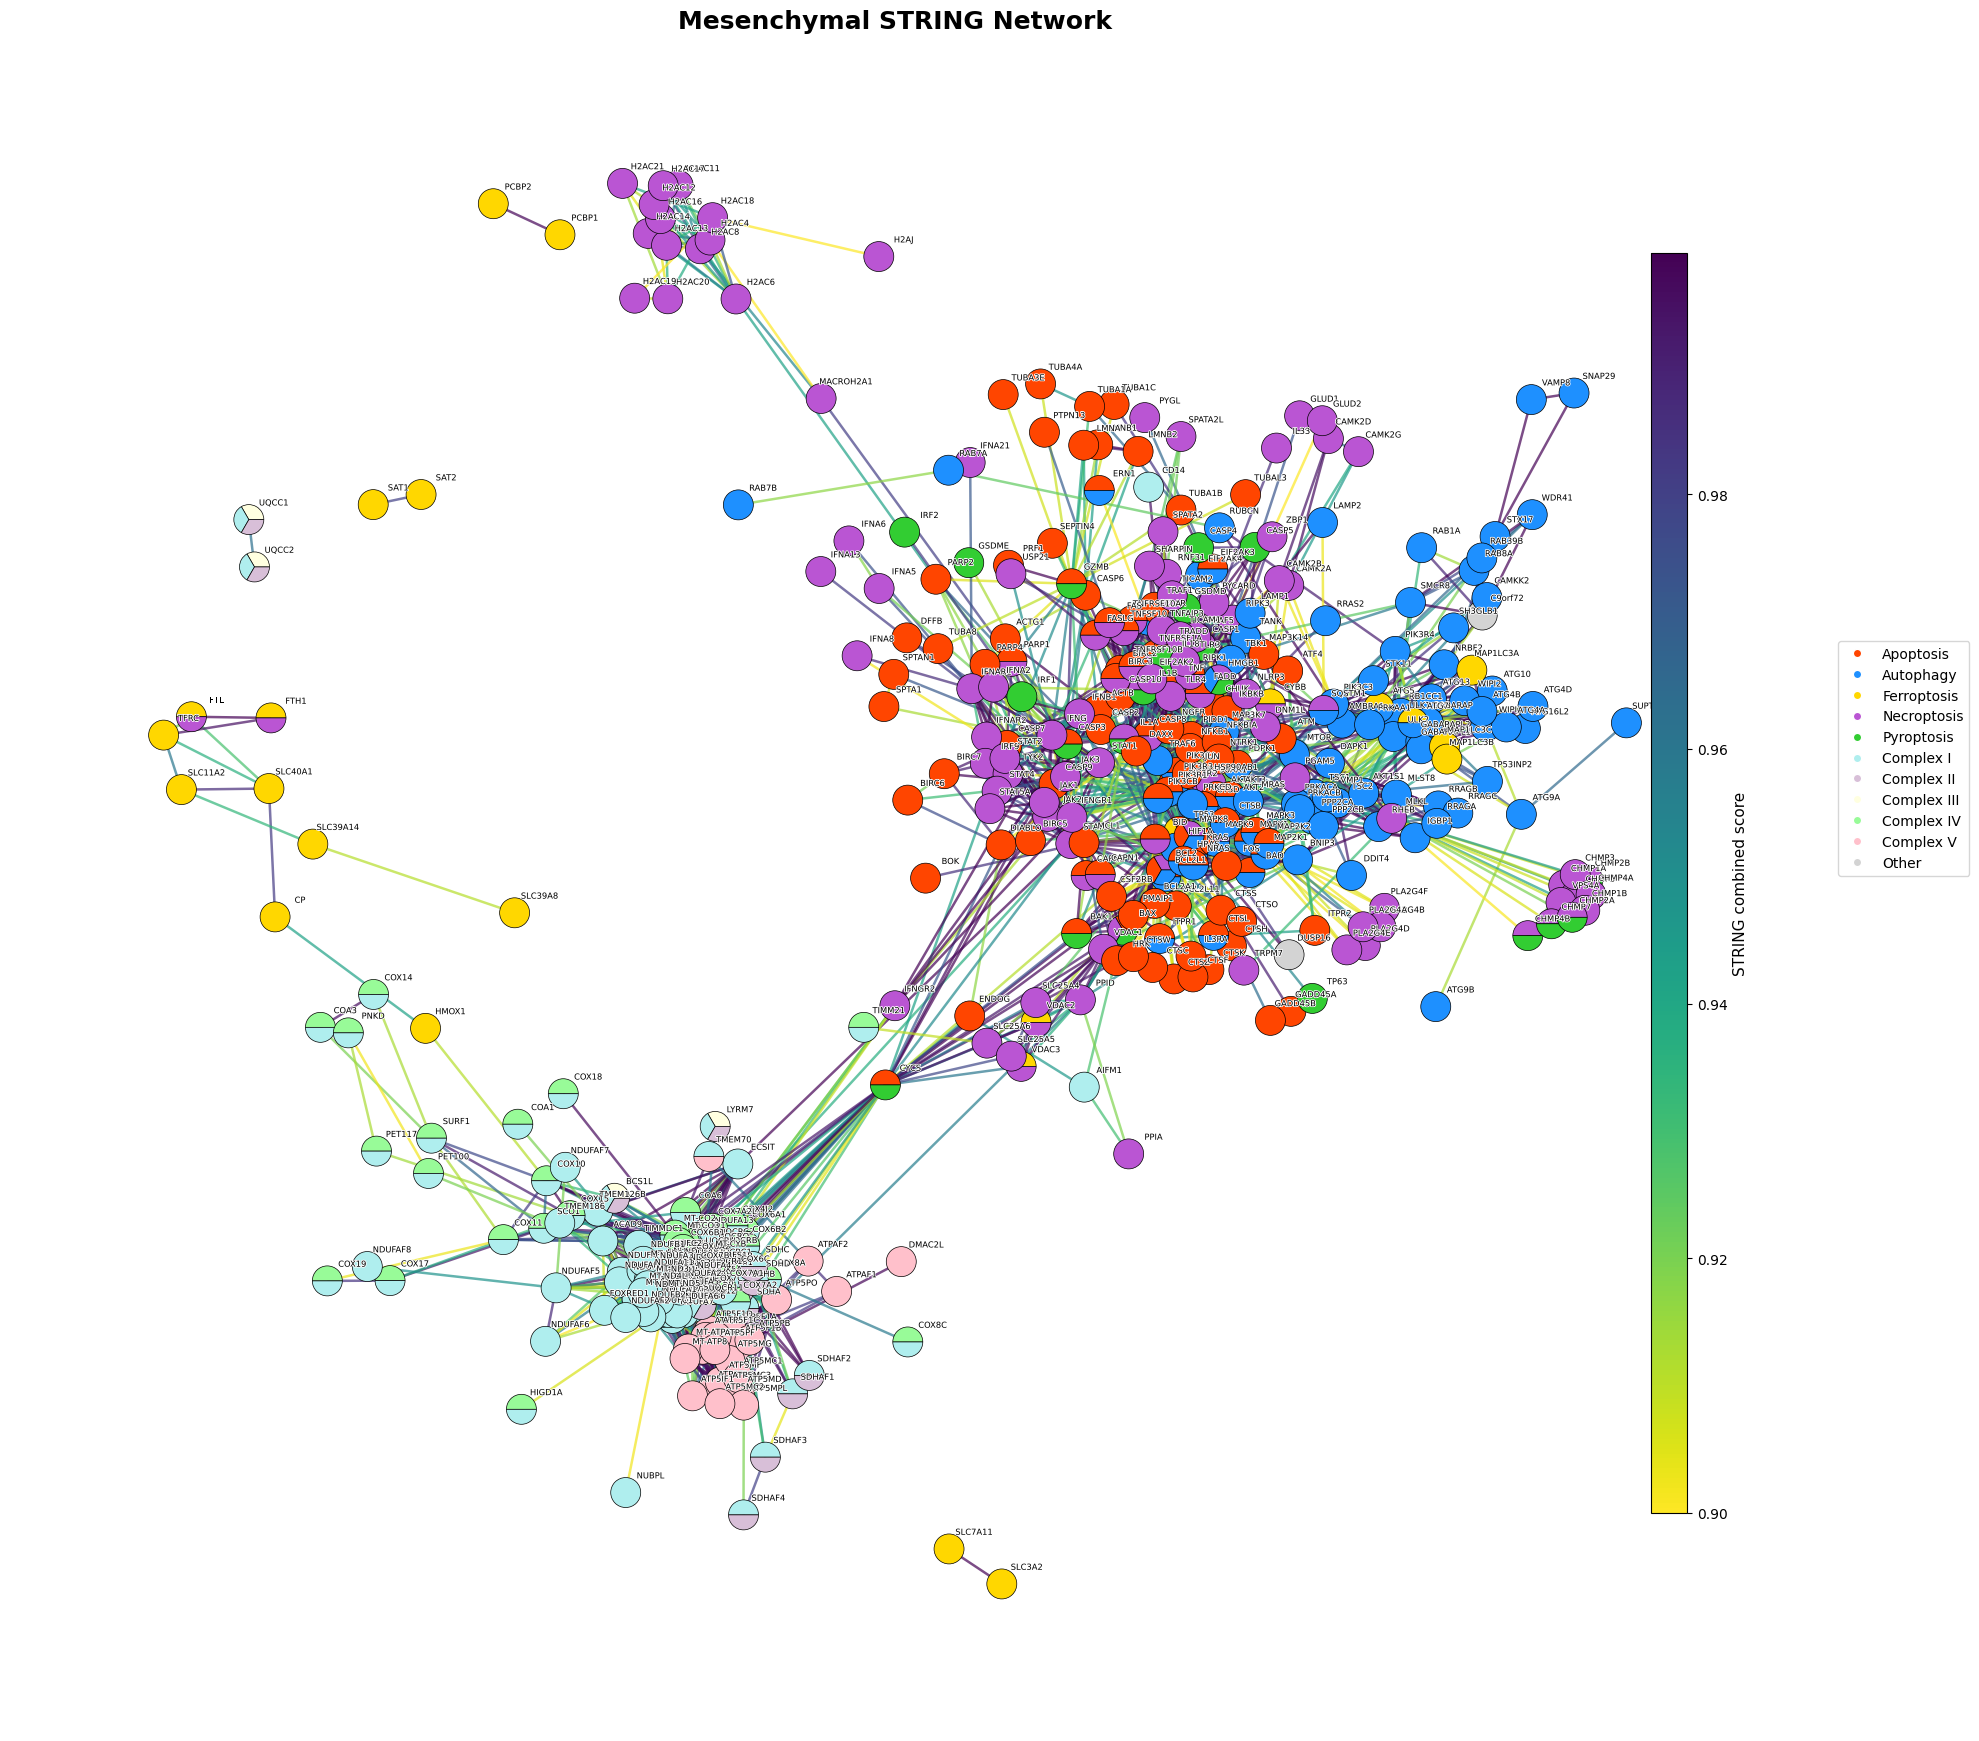

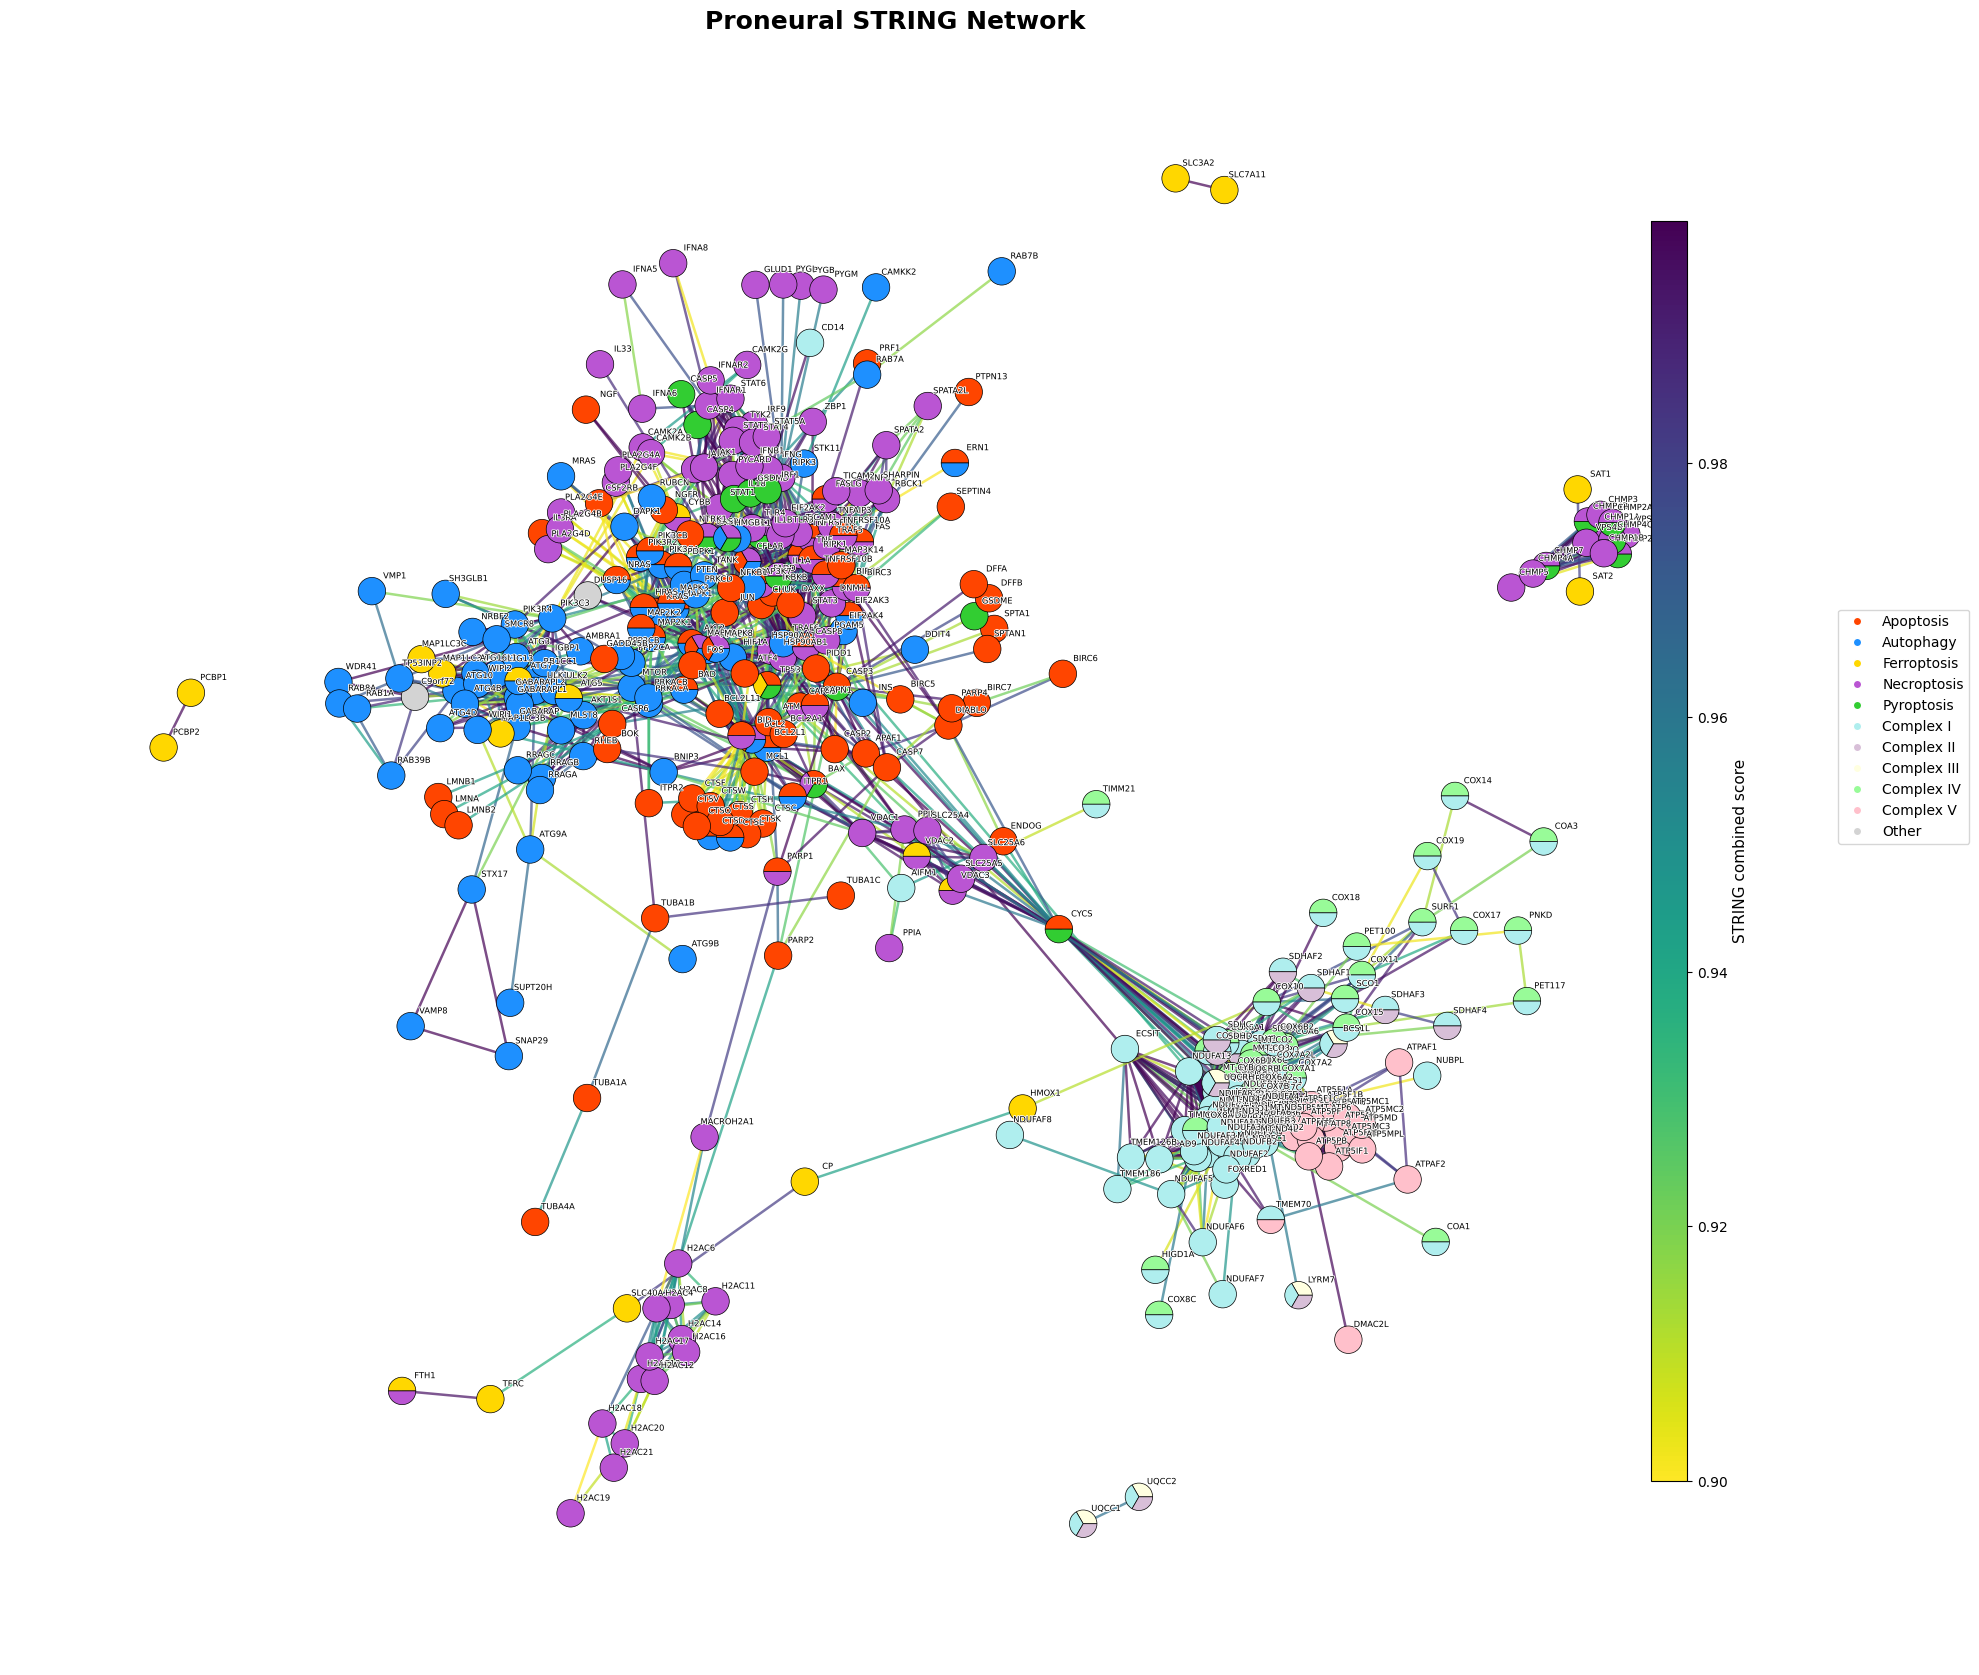

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D
import matplotlib as mpl
import networkx as nx


# --------------------------------------------------
# COLORS
# --------------------------------------------------

pathway_colors = {
    "Apoptosis": "orangered",
    "Autophagy": "dodgerblue",
    "Ferroptosis": "gold",
    "Necroptosis": "mediumorchid",
    "Pyroptosis": "limegreen"
}

complex_colors = {
    "Complex I": "paleturquoise",
    "Complex II": "thistle",
    "Complex III": "lightyellow",
    "Complex IV": "palegreen",
    "Complex V": "pink"
}

radius = 0.018


# --------------------------------------------------
# LOOP THROUGH SUBTYPES
# --------------------------------------------------

for subtype in subtypes:

    G = graphs[subtype]

    # --------------------------------------------------
    # LAYOUT
    # --------------------------------------------------

    pos = nx.spring_layout(
        G,
        seed=42,
        k=2.3,
        iterations=1000
    )


    # --------------------------------------------------
    # FIGURE
    # --------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(18, 18)
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )


    ##################################################
    # EDGES COLORED BY STRING COMBINED SCORE
    ##################################################

    scores = [
        G[u][v]["combined_score"]
        for u, v in G.edges()
    ]

    vmin = min(scores)
    vmax = max(scores)

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=scores,
        edge_cmap=plt.cm.viridis_r,
        edge_vmin=vmin,
        edge_vmax=vmax,
        width=1.8,
        alpha=0.7,
        ax=ax
    )


    ##################################################
    # STRING SCORE COLORBAR
    ##################################################

    norm = mpl.colors.Normalize(
        vmin=vmin,
        vmax=vmax
    )

    sm = mpl.cm.ScalarMappable(
        cmap=plt.cm.viridis_r,
        norm=norm
    )

    sm.set_array([])

    cax = fig.add_axes(
        [0.92, 0.15, 0.02, 0.70]
    )

    cbar = fig.colorbar(
        sm,
        cax=cax
    )

    cbar.set_label(
        "STRING combined score",
        fontsize=11
    )


    ##################################################
    # DRAW NODES
    ##################################################

    for gene in G.nodes():

        x, y = pos[gene]

        colors = []

        # -------- Pathways --------

        for pathway in G.nodes[gene]["Pathways"]:

            if pathway in pathway_colors:

                colors.append(
                    pathway_colors[pathway]
                )

        # -------- Complexes --------

        for comp in G.nodes[gene]["Complexes"]:

            if comp in complex_colors:

                colors.append(
                    complex_colors[comp]
                )


        # -------- Draw --------

        if len(colors) == 0:

            node = Circle(
                (x, y),
                radius,
                facecolor="lightgray",
                edgecolor="black",
                linewidth=0.5
            )

            ax.add_patch(node)


        elif len(colors) == 1:

            node = Circle(
                (x, y),
                radius,
                facecolor=colors[0],
                edgecolor="black",
                linewidth=0.5
            )

            ax.add_patch(node)


        else:

            angle = 360 / len(colors)

            for i, color in enumerate(colors):

                wedge = Wedge(
                    (x, y),
                    radius,
                    theta1=i * angle,
                    theta2=(i + 1) * angle,
                    facecolor=color,
                    edgecolor="black",
                    linewidth=0.5
                )

                ax.add_patch(wedge)


    ##################################################
    # LABELS
    ##################################################

    label_pos = {
        gene: (
            xy[0] + 0.03,
            xy[1] + 0.02
        )
        for gene, xy in pos.items()
    }

    texts = nx.draw_networkx_labels(
        G,
        label_pos,
        labels={
            g: g
            for g in G.nodes()
        },
        font_size=6,
        font_color="black",
        font_family="sans-serif",
        ax=ax
    )

    for t in texts.values():

        t.set_path_effects([
            pe.Stroke(
                linewidth=1.2,
                foreground="white"
            ),
            pe.Normal()
        ])


    ##################################################
    # LEGEND
    ##################################################

    legend = [

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=pathway_colors["Apoptosis"],
            label="Apoptosis"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=pathway_colors["Autophagy"],
            label="Autophagy"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=pathway_colors["Ferroptosis"],
            label="Ferroptosis"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=pathway_colors["Necroptosis"],
            label="Necroptosis"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=pathway_colors["Pyroptosis"],
            label="Pyroptosis"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=complex_colors["Complex I"],
            label="Complex I"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=complex_colors["Complex II"],
            label="Complex II"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=complex_colors["Complex III"],
            label="Complex III"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=complex_colors["Complex IV"],
            label="Complex IV"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=complex_colors["Complex V"],
            label="Complex V"
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="lightgray",
            label="Other"
        )

    ]

    fig.legend(
        handles=legend,
        loc="lower left",
        bbox_to_anchor=(1.02, 0.5)
    )


    ##################################################
    # TITLE
    ##################################################

    ax.set_title(
        f"{subtype.capitalize()} STRING Network",
        fontsize=18,
        fontweight="bold"
    )


    ##################################################
    # FINISH
    ##################################################

    ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"../data/interim/network_stat/"
        f"{subtype}/{subtype}_network.svg",
        format="svg",
        bbox_inches="tight"
    )

    plt.show()

In [33]:
#EDGE COUNT - INTERNAL OVERLAP

import pandas as pd

complex_order = [
    "Complex I",
    "Complex II",
    "Complex III",
    "Complex IV",
    "Complex V"
]

for subtype in subtypes:

    G = graphs[subtype]

    rows = []

    for pathway in pathways:

        row = {
            "Pathway": pathway
        }

        for complex_name in complex_order:

            count = 0

            for u, v in G.edges():

                u_path = pathway in G.nodes[u]["Pathways"]
                v_path = pathway in G.nodes[v]["Pathways"]

                u_comp = complex_name in G.nodes[u]["Complexes"]
                v_comp = complex_name in G.nodes[v]["Complexes"]

                # Count edge if at least one endpoint
                # belongs to pathway AND
                # at least one endpoint belongs to complex
                if (u_path or v_path) and (u_comp or v_comp):

                    count += 1

            row[complex_name] = count

        rows.append(row)

    table = pd.DataFrame(rows)

    print(f"\n{subtype.upper()} Edge Count")
    print(table)

    table.to_csv(
        f"../data/interim/network_stat/{subtype}/{subtype}_complex_pathway_edge_counts.csv",
        index=False
    )


CLASSICAL Edge Count
       Pathway  Complex I  Complex II  Complex III  Complex IV  Complex V
0    Apoptosis         25          13            9          10          0
1    Autophagy          1           0            0           0          0
2  Ferroptosis          1           0            0           1          0
3  Necroptosis          5           0            0           1          1
4   Pyroptosis         24          13            9          10          0

MESENCHYMAL Edge Count
       Pathway  Complex I  Complex II  Complex III  Complex IV  Complex V
0    Apoptosis         25          13            9          10          0
1    Autophagy          1           0            0           0          0
2  Ferroptosis          1           0            0           1          0
3  Necroptosis          9           4            4           1          1
4   Pyroptosis         24          13            9          10          0

PRONEURAL Edge Count
       Pathway  Complex I  Complex II  Compl

In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt

complex_order = [
    "Complex I",
    "Complex II",
    "Complex III",
    "Complex IV",
    "Complex V"
]

complex_colors = {
    "Complex I": "paleturquoise",
    "Complex II": "thistle",
    "Complex III": "lightyellow",
    "Complex IV": "palegreen",
    "Complex V": "pink"
}

pathway_colors = {
    "Apoptosis": "orangered",
    "Autophagy": "dodgerblue",
    "Ferroptosis": "gold",
    "Necroptosis": "mediumorchid",
    "Pyroptosis": "limegreen"
}

for subtype in subtypes:

    G = graphs[subtype]

    complex_counts = {
        complex_name: sum(
            complex_name in G.nodes[gene]["Complexes"]
            for gene in G.nodes()
        )
        for complex_name in complex_order
    }

    pathway_counts = {
        pathway: sum(
            pathway in G.nodes[gene]["Pathways"]
            for gene in G.nodes()
        )
        for pathway in pathways
    }

    labels = complex_order + pathways
    values = [complex_counts[c] for c in complex_order] + [pathway_counts[p] for p in pathways]
    colors = [complex_colors[c] for c in complex_order] + [pathway_colors[p] for p in pathways]

    fig, ax = plt.subplots(figsize=(12, 5))

    bars = ax.bar(
        labels,
        values,
        color=colors,
        edgecolor="black",
        linewidth=0.8
    )

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(
        f"{subtype.capitalize()} - complex and pathway gene counts",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Category")
    ax.set_ylabel("Gene count")
    ax.set_ylim(0, max(values + [1]) * 1.2)
    ax.tick_params(axis="x", rotation=25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_dir = os.path.join(
        "../data/interim/network_stat",
        subtype
    )
    os.makedirs(out_dir, exist_ok=True)

    fig.savefig(
        os.path.join(
            out_dir,
            f"{subtype}_complex_pathway_gene_counts.svg"
        ),
        format="svg",
        bbox_inches="tight"
    )
    plt.close(fig)


# Per-Pathway Inspection

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx

from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Wedge


center_pathway = "Apoptosis"

for subtype in subtypes:


    for pathway in pathways:
        center_pathway = pathway
        
        
        G = graphs[subtype]

        pair_complexes = [
            "Complex I",
            "Complex II",
            "Complex III",
            "Complex IV",
            "Complex V"
        ]

        pathway_colors = {
            "Apoptosis": "orangered",
            "Autophagy": "dodgerblue",
            "Ferroptosis": "darkcyan",
            "Necroptosis": "darkslateblue",
            "Pyroptosis": "crimson"
        }


        complex_colors = {
            "Complex I": "paleturquoise",
            "Complex II": "thistle",
            "Complex III": "lightyellow",
            "Complex IV": "palegreen",
            "Complex V": "pink"
        }

        radius = 0.02

        for complex_name in pair_complexes:
            
            ##################################################
            # Keep ONLY:
            #   - apoptosis genes
            #   - selected complex genes
            ##################################################

            nodes_to_plot = [
                gene
                for gene in G.nodes()
                if (
                    center_pathway in G.nodes[gene]["Pathways"]
                    or
                    complex_name in G.nodes[gene]["Complexes"]
                )
            ]

            G_plot = G.subgraph(nodes_to_plot).copy()
            import matplotlib as mpl

            log2fcs = [
                G_plot.nodes[g]["log2FC"]
                for g in G_plot.nodes()
            ]

            fc_norm = mpl.colors.TwoSlopeNorm(
                vmin=min(log2fcs),
                vcenter=0,
                vmax=max(log2fcs)
            )

            fc_cmap = plt.cm.coolwarm
        
            sm_fc = mpl.cm.ScalarMappable(
                cmap=fc_cmap,
                norm=fc_norm
            )
            sm_fc.set_array([])



            ##################################################
            # Layout
            ##################################################

            pos = nx.spring_layout(
                G,
                seed=42,
                k=2.3,
                iterations=1000,
                scale = 1.1
            )

            fig, ax = plt.subplots(figsize=(14,14))

            ax.set_aspect("equal", adjustable="box")
            
            ##################################################
            # Edges colored by STRING confidence
            ##################################################

            from mpl_toolkits.axes_grid1 import make_axes_locatable
            import matplotlib as mpl

            scores = [
                G_plot[u][v]["combined_score"]
                for u, v in G_plot.edges()
            ]

            vmin = min(scores)
            vmax = max(scores)

            nx.draw_networkx_edges(
                G_plot,
                pos,
                edge_color=scores,
                edge_cmap=plt.cm.viridis_r,
                edge_vmin=vmin,
                edge_vmax=vmax,
                width=1,
                alpha=0.8,
                ax=ax
            )


            ##################################################
            # STRING score colorbar
            ##################################################

            import matplotlib as mpl

            norm = mpl.colors.Normalize(
                vmin=vmin,
                vmax=vmax
            )

            sm = mpl.cm.ScalarMappable(
                cmap=plt.cm.viridis_r,
                norm=norm
            )
            sm.set_array([])

            # left colorbar
            cax1 = fig.add_axes([1.08, 0.15, 0.02, 0.70])

            cbar = fig.colorbar(
                sm,
                cax=cax1
            )

            cbar.set_label(
                "STRING combined score",
                fontsize=11
            )

            ##################################################
            # log2FC colorbar
            ##################################################

            fc_norm = mpl.colors.TwoSlopeNorm(
                vmin=min(log2fcs),
                vcenter=0,
                vmax=max(log2fcs)
            )

            fc_cmap = plt.cm.coolwarm

            sm_fc = mpl.cm.ScalarMappable(
                cmap=fc_cmap,
                norm=fc_norm
            )
            sm_fc.set_array([])

            # second colorbar further left
            cax2 = fig.add_axes([1.02, 0.15, 0.02, 0.70])

            cbar_fc = fig.colorbar(
                sm_fc,
                cax=cax2
            )

            cbar_fc.set_label(
                r"$\log_2$ fold change",
                fontsize=11
            )
            ##################################################
            # Nodes
            ##################################################


            

            for gene in G_plot.nodes():

                x, y = pos[gene]

                fill = fc_cmap(
                    fc_norm(G_plot.nodes[gene]["log2FC"])
                )

                apoptosis = center_pathway in G_plot.nodes[gene]["Pathways"]
                complex_member = complex_name in G_plot.nodes[gene]["Complexes"]

                # outline color
                if apoptosis and complex_member:
                    edgecolor = "black"      # both
                elif apoptosis:
                    edgecolor = pathway_colors[center_pathway]
                elif complex_member:
                    edgecolor = complex_colors[complex_name]
                else:
                    edgecolor = "lightgray"

                ax.add_patch(
                    Circle(
                        (x, y),
                        radius,
                        facecolor=fill,
                        edgecolor=edgecolor,
                        linewidth=1.8
                    )
                )


            ##################################################
            # Labels
            ##################################################

            label_pos = {
                gene: (xy[0] + 0.03, xy[1] + 0.02)
                for gene, xy in pos.items()
            }

            texts = nx.draw_networkx_labels(
                G_plot,
                label_pos,
                labels={g: g for g in G_plot.nodes()},
                font_size=7,
                font_family="sans-serif",
                font_color="black",
                ax=ax
            )

            for t in texts.values():

                t.set_path_effects([
                    pe.Stroke(
                        linewidth=1.2,
                        foreground="white"
                    ),
                    pe.Normal()
                ])

            ##################################################
            # Legend
            ##################################################

            legend = [

                Line2D(
                    [0], [0],
                    marker="o",
                    color="w",
                    markerfacecolor=pathway_colors[center_pathway],
                    label=center_pathway
                ),

                Line2D(
                    [0], [0],
                    marker="o",
                    color="w",
                    markerfacecolor=complex_colors[complex_name],
                    label=complex_name
                ),

                Line2D(
                    [0], [0],
                    marker="o",
                    color="w",
                    markerfacecolor="white",
                    markeredgecolor="black",
                    label=f"{center_pathway} + {complex_name}"
                )

            ]

            ax.legend(
                handles=legend,
                loc="upper right"
            )

            ##################################################
            # Finish
            ##################################################

            ax.set_title(
                f"{subtype.capitalize()} : {center_pathway} vs {complex_name}",
                fontsize=16,
                fontweight="bold"
            )

            ax.axis("off")

            plt.tight_layout()

            plt.savefig(
                f"../data/interim/network_stat/{subtype}/{center_pathway.lower()}/{subtype}_{center_pathway.lower()}_{complex_name.lower().replace(' ', '_')}.svg",
                format="svg",
                bbox_inches="tight"
            )

            plt.close(fig)
            #plt.show()

C:\Users\haina\AppData\Local\Temp\ipykernel_24896\3774544042.py:311: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [46]:
import os
import matplotlib.pyplot as plt

subtype = "classical"
G = graphs[subtype]

complex_order = [
    "Complex I",
    "Complex II",
    "Complex III",
    "Complex IV",
    "Complex V"
]

complex_colors = {
    "Complex I": "paleturquoise",
    "Complex II": "thistle",
    "Complex III": "lightyellow",
    "Complex IV": "palegreen",
    "Complex V": "pink"
}

pathway_colors = {
    "Apoptosis": "orangered"
}

complex_counts = {
    complex_name: sum(
        complex_name in G.nodes[gene]["Complexes"]
        for gene in G.nodes()
    )
    for complex_name in complex_order
}

apoptosis_count = sum(
    "Apoptosis" in G.nodes[gene]["Pathways"]
    for gene in G.nodes()
)

labels = complex_order + ["Apoptosis"]
values = [complex_counts[c] for c in complex_order] + [apoptosis_count]
colors = [complex_colors[c] for c in complex_order] + [pathway_colors["Apoptosis"]]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    labels,
    values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Complex and apoptotic gene counts",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Category")
ax.set_ylabel("Gene count")
ax.set_ylim(0, max(values + [1]) * 1.2)
ax.tick_params(axis="x", rotation=25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

out_dir = os.path.join("../data/interim/network_stat", subtype)
os.makedirs(out_dir, exist_ok=True)

fig.savefig(
    os.path.join(out_dir, f"{subtype}_complex_apoptosis_gene_counts.svg"),
    format="svg",
    bbox_inches="tight"
)
plt.close(fig)


# ============ IGNORE: THESIS-SPECIFIC PLOT =======================

Nodes: 240
Edges: 3371


C:\Users\haina\AppData\Local\Temp\ipykernel_24896\146730888.py:364: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


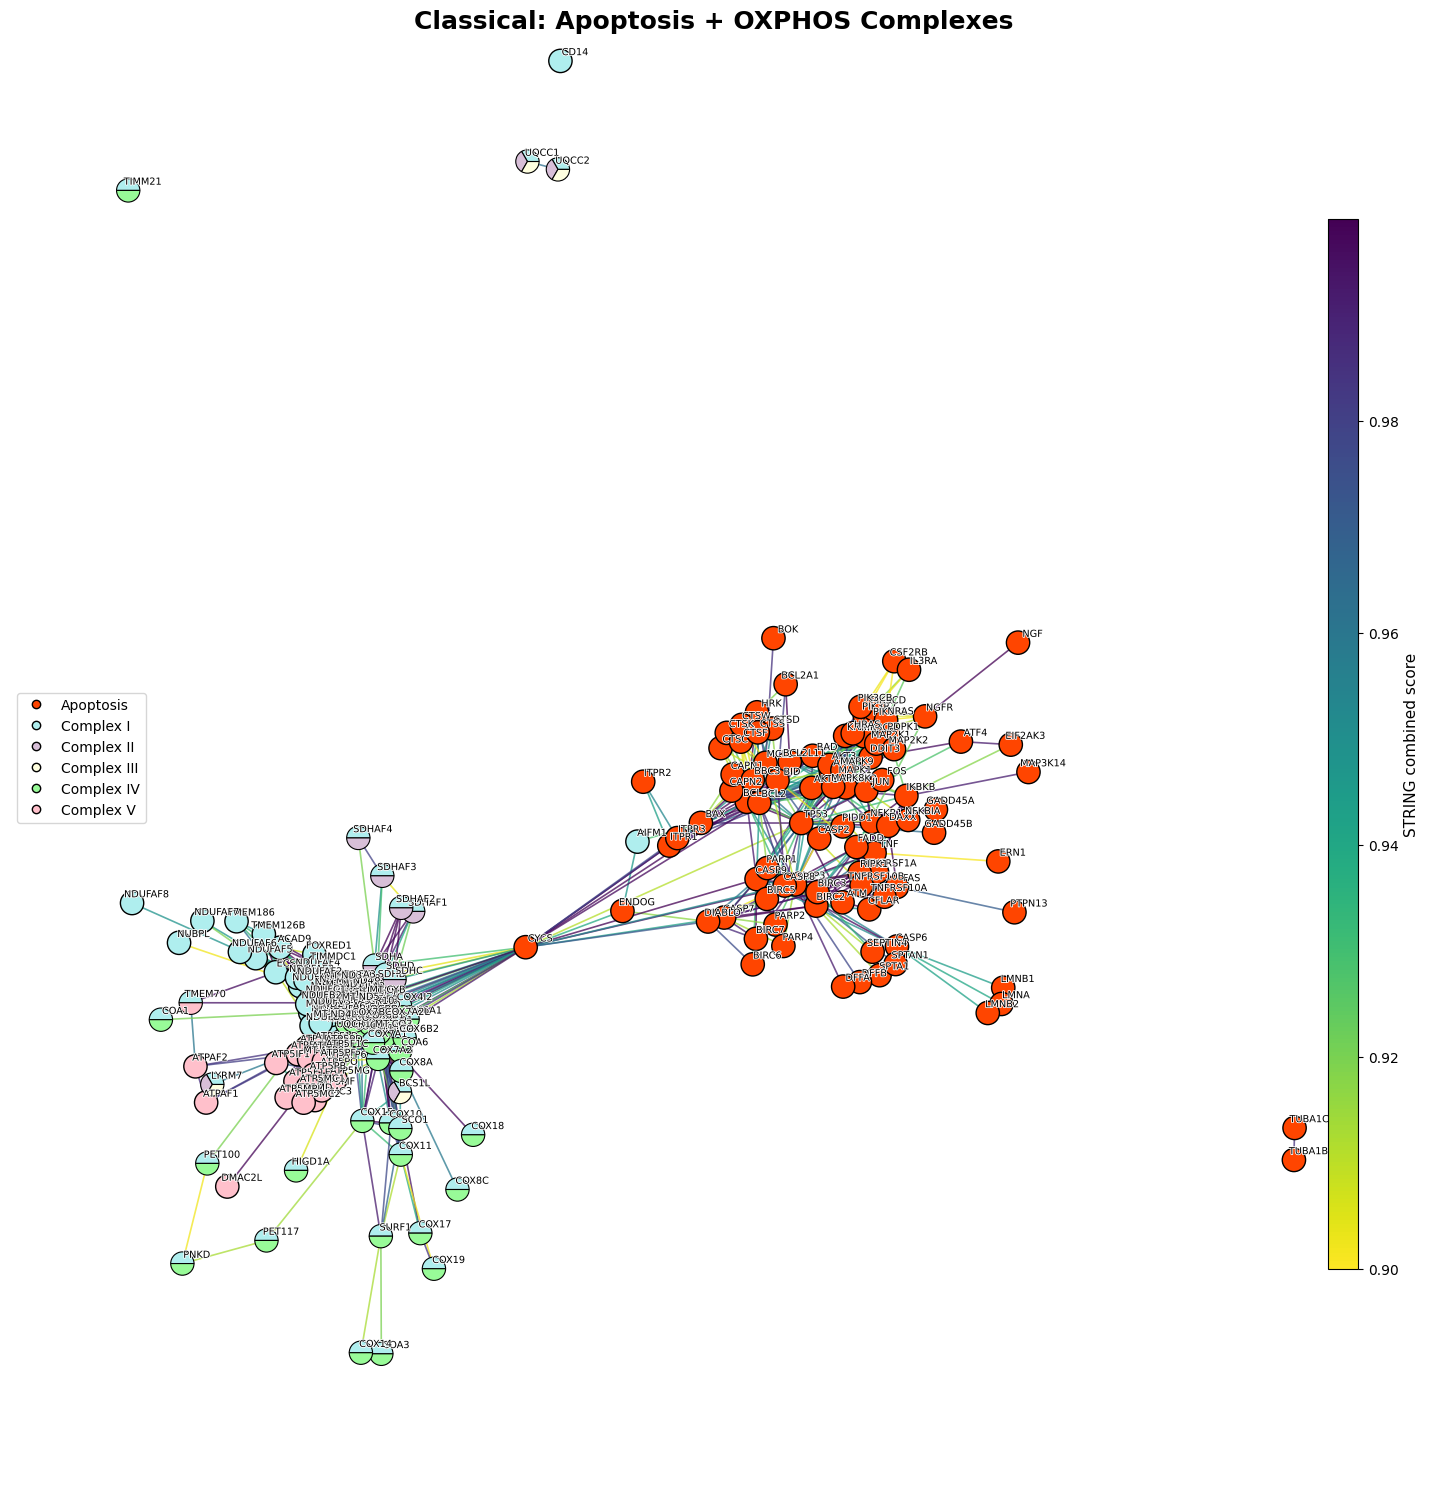

In [57]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import matplotlib.patheffects as pe

from matplotlib.patches import Circle, Wedge
from matplotlib.lines import Line2D


# ============================================================
# SETTINGS
# ============================================================

subtype = "classical"
center_pathway = "Apoptosis"

complexes_to_plot = [
    "Complex I",
    "Complex II",
    "Complex III",
    "Complex IV",
    "Complex V"
]

pathway_color = "orangered"

complex_colors = {
    "Complex I": "paleturquoise",
    "Complex II": "thistle",
    "Complex III": "lightyellow",
    "Complex IV": "palegreen",
    "Complex V": "pink"
}

radius = 0.02


# ============================================================
# GET GRAPH
# ============================================================

G = graphs[subtype]


# ============================================================
# SELECT APOPTOSIS + OXPHOS GENES
# ============================================================

nodes_to_plot = [
    gene
    for gene in G.nodes()
    if (
        center_pathway in G.nodes[gene]["Pathways"]
        or
        any(
            complex_name in G.nodes[gene]["Complexes"]
            for complex_name in complexes_to_plot
        )
    )
]

G_plot = G.subgraph(nodes_to_plot).copy()

print("Nodes:", G_plot.number_of_nodes())
print("Edges:", G_plot.number_of_edges())


# ============================================================
# LAYOUT
# ============================================================

pos = nx.spring_layout(
    G_plot,
    seed=42,
    k=1.7,
    iterations=1000,
    scale=1.5
)


# ============================================================
# STRING SCORE COLOR SCALE
# ============================================================

scores = [
    G_plot[u][v]["combined_score"]
    for u, v in G_plot.edges()
]

score_norm = mpl.colors.Normalize(
    vmin=min(scores),
    vmax=max(scores)
)


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(15,15)
)

ax.set_aspect(
    "equal",
    adjustable="box"
)


# ============================================================
# EDGES — STRING COMBINED SCORE
# ============================================================

nx.draw_networkx_edges(
    G_plot,
    pos,
    edge_color=scores,
    edge_cmap=plt.cm.viridis_r,
    edge_vmin=min(scores),
    edge_vmax=max(scores),
    width=1.2,
    alpha=0.75,
    ax=ax
)


# ============================================================
# STRING SCORE COLORBAR
# ============================================================

sm_score = mpl.cm.ScalarMappable(
    cmap=plt.cm.viridis_r,
    norm=score_norm
)

sm_score.set_array([])

cax = fig.add_axes(
    [0.91, 0.15, 0.02, 0.70]
)

cbar = fig.colorbar(
    sm_score,
    cax=cax
)

cbar.set_label(
    "STRING combined score",
    fontsize=11
)


# ============================================================
# NODES
# ============================================================

for gene in G_plot.nodes():

    x, y = pos[gene]

    pathways_gene = G_plot.nodes[gene]["Pathways"]
    complexes_gene = G_plot.nodes[gene]["Complexes"]

    # --------------------------------------------------------
    # APOPTOSIS?
    # --------------------------------------------------------

    is_apoptosis = (
        center_pathway in pathways_gene
    )

    # --------------------------------------------------------
    # WHICH COMPLEXES?
    # --------------------------------------------------------

    gene_complexes = [
        c
        for c in complexes_to_plot
        if c in complexes_gene
    ]


    # ========================================================
    # BUILD NODE COLORS
    # ========================================================

    colors = []

    # Apoptosis gets its own color
    if is_apoptosis:
        colors.append(
            pathway_color
        )

    # Add every OXPHOS complex the gene belongs to
    for complex_name in gene_complexes:

        colors.append(
            complex_colors[complex_name]
        )


    # ========================================================
    # DRAW NODE
    # ========================================================

    # --------------------------------------------------------
    # One annotation → solid circle
    # --------------------------------------------------------

    if len(colors) == 1:

        ax.add_patch(
            Circle(
                (x, y),
                radius,
                facecolor=colors[0],
                edgecolor="black",
                linewidth=1.0
            )
        )


    # --------------------------------------------------------
    # Multiple annotations → wedges
    # --------------------------------------------------------

    elif len(colors) > 1:

        angle = 360 / len(colors)

        for i, color in enumerate(colors):

            wedge = Wedge(
                (x, y),
                radius,
                theta1=i * angle,
                theta2=(i + 1) * angle,
                facecolor=color,
                edgecolor="black",
                linewidth=0.8
            )

            ax.add_patch(wedge)


# ============================================================
# LABELS
# ============================================================

label_pos = {
    gene: (
        xy[0] + 0.025,
        xy[1] + 0.015
    )
    for gene, xy in pos.items()
}

texts = nx.draw_networkx_labels(
    G_plot,
    label_pos,
    labels={
        g: g
        for g in G_plot.nodes()
    },
    font_size=7,
    font_family="sans-serif",
    font_color="black",
    ax=ax
)

for text in texts.values():

    text.set_path_effects([
        pe.Stroke(
            linewidth=1.2,
            foreground="white"
        ),
        pe.Normal()
    ])


# ============================================================
# LEGEND
# ============================================================

legend = [

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=pathway_color,
        markeredgecolor="black",
        label="Apoptosis"
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=complex_colors["Complex I"],
        markeredgecolor="black",
        label="Complex I"
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=complex_colors["Complex II"],
        markeredgecolor="black",
        label="Complex II"
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=complex_colors["Complex III"],
        markeredgecolor="black",
        label="Complex III"
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=complex_colors["Complex IV"],
        markeredgecolor="black",
        label="Complex IV"
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=complex_colors["Complex V"],
        markeredgecolor="black",
        label="Complex V"
    )
]


ax.legend(
    handles=legend,
    loc="center left",
    fontsize=10
)


# ============================================================
# FINISH
# ============================================================

ax.set_title(
    "Classical: Apoptosis + OXPHOS Complexes",
    fontsize=18,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()

plt.show()